# Behold the Optical Pumping

In [1]:
# !pip install uncertainties
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uncertainties
import os

In [2]:
# Converting the sweep values to b field values:
def add_magnetic_field(filename, timeconst):
    ItB = (0.6*1e-4)#Teslas
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)/10
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*timeconst
    filename, ext = os.path.splitext(filename)
    new_filename = f"{filename}_B{ext}"
    df.to_csv(new_filename, index=False)
    print("New file:",new_filename) 
    return df

df_25 = add_magnetic_field("linear_zeeman_data/NewFile25kHz.csv",5.000000e-03)
df_50 = add_magnetic_field("linear_zeeman_data/NewFile50kHz.csv",5.000000e-03)
df_75 = add_magnetic_field("linear_zeeman_data/NewFile75kHz.csv",5.000000e-03)
df_100 = add_magnetic_field("linear_zeeman_data/NewFile100kHz.csv",5.000000e-03)
df_125 = add_magnetic_field("linear_zeeman_data/NewFile125kHz.csv",5.000000e-03)
df_150 = add_magnetic_field("linear_zeeman_data/NewFile150kHz.csv",5.000000e-03)
df_175 = add_magnetic_field("linear_zeeman_data/NewFile175kHz.csv",5.000000e-03)
df_195 = add_magnetic_field("linear_zeeman_data/NewFile195kHz.csv",5.000000e-03)
df_300 = add_magnetic_field("linear_zeeman_data/300kHz_5s.csv",5.000000e-03)
df_500 = add_magnetic_field("linear_zeeman_data/500kHz_5s.csv",5.000000e-03)
df_600 = add_magnetic_field("linear_zeeman_data/600kHz_5s.csv",5.000000e-03)
df_700_1 = add_magnetic_field("linear_zeeman_data/700kHz_5s_43.csv",5.000000e-03)
df_700_2 = add_magnetic_field("linear_zeeman_data/700kHz_5s_72.csv",5.000000e-03)
df = [df_25,df_50,df_75,df_100,df_125,df_150,df_175,df_195]
df_300["Bfield"] = (df_300["Bfield"]*10)+(22*1.6432432432432434e-06)
df_500["Bfield"] = (df_500["Bfield"]*10)+(44*1.6432432432432434e-06)
df_600["Bfield"] = (df_600["Bfield"]*10)+(58*1.6432432432432434e-06)
df_700_1["Bfield"] = (df_700_2["Bfield"]*10)+(45*1.6432432432432434e-06)
df_700_2["Bfield"] = (df_700_2["Bfield"]*10)+(74*1.6432432432432434e-06)
dff = [df_300,df_500,df_600]
dfff = [df_700_1,df_700_2]

New file: linear_zeeman_data/NewFile25kHz_B.csv
New file: linear_zeeman_data/NewFile50kHz_B.csv
New file: linear_zeeman_data/NewFile75kHz_B.csv
New file: linear_zeeman_data/NewFile100kHz_B.csv
New file: linear_zeeman_data/NewFile125kHz_B.csv
New file: linear_zeeman_data/NewFile150kHz_B.csv
New file: linear_zeeman_data/NewFile175kHz_B.csv
New file: linear_zeeman_data/NewFile195kHz_B.csv
New file: linear_zeeman_data/300kHz_5s_B.csv
New file: linear_zeeman_data/500kHz_5s_B.csv
New file: linear_zeeman_data/600kHz_5s_B.csv
New file: linear_zeeman_data/700kHz_5s_43_B.csv
New file: linear_zeeman_data/700kHz_5s_72_B.csv


### Lorentzian fit of the data:

$$f(x;A,x_0,\gamma) = A\cdot\frac{\gamma^2}{\gamma^2+(x-x_0)^2}$$

In [3]:
def lorentzian(x, y0, a1, c1, w1):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    return y0 + L1

In [4]:
def double_lorentzian(x, y0, a1, c1, w1, a2, c2, w2):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    return y0 + L1 + L2

In [5]:
def triple_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    return y0 + L1 + L2 + L3

In [6]:
def fit_triple_lorentzian(p0, df, result_list):
    x_data, y_data = df["time"], df["CH2norm"]
    popt, pcov = curve_fit(triple_lorentzian, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    print(f"Lorentzian peak 1: {popt[2]:.4f} \u00b1 {perr[2]:.4f}")
    print(f"Lorentzian peak 2: {popt[5]:.4f} \u00b1 {perr[5]:.4f}")
    print(f"Lorentzian peak 3: {popt[8]:.4f} \u00b1 {perr[8]:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, triple_lorentzian(x_data, *popt), 'r-',
             linewidth=2, label='Fitted Triple Lorentzian')
    plt.scatter([p0[2], p0[5], p0[8]], [p0[1], p0[4], p0[7]],
                color='black', marker='x', label='Initial Guesses', zorder=5)
    plt.xlabel('Time (s)')
    plt.ylabel('CH2norm (Normalized Intensity)')
    plt.title('Triple Lorentzian Multi-Peak Fit')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    # Store peak centers and their uncertainties: [c2, c3, err_c2, err_c3]
    result_list.append([popt[5], popt[8], perr[5], perr[8]])
    return popt, perr

Lorentzian peak 1: 2.0297 ± 0.0006
Lorentzian peak 2: 2.5016 ± 0.0007
Lorentzian peak 3: 2.3444 ± 0.0014


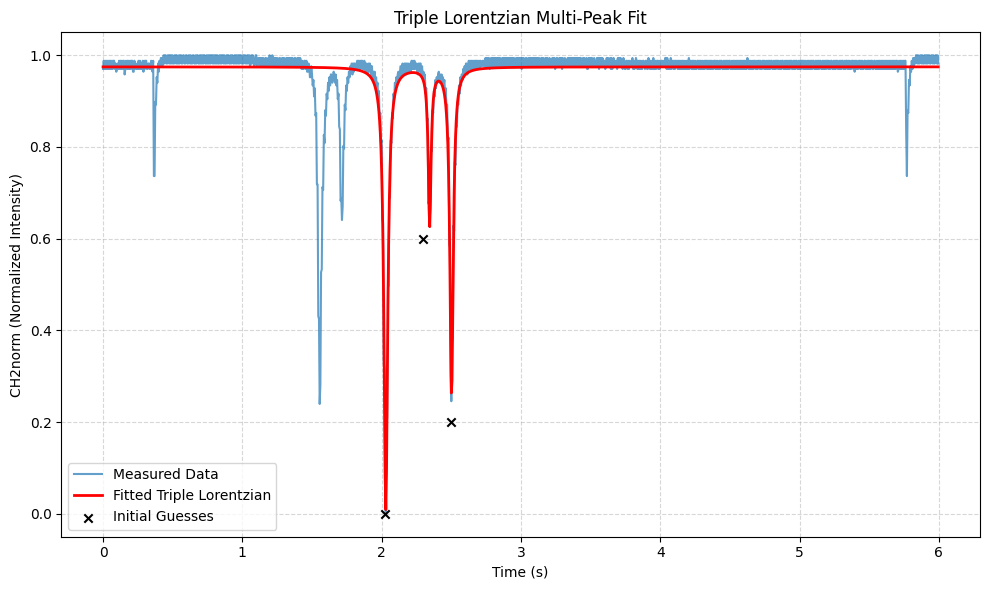

Lorentzian peak 1: 2.1808 ± 0.0012
Lorentzian peak 2: 3.1231 ± 0.0010
Lorentzian peak 3: 2.8085 ± 0.0019


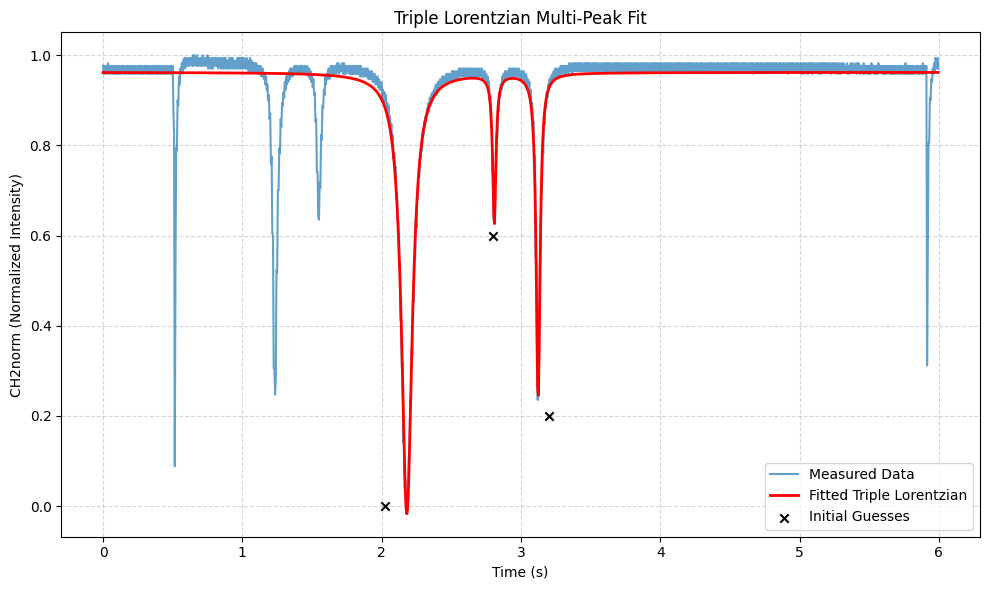

Lorentzian peak 1: 2.1669 ± 0.0015
Lorentzian peak 2: 3.5827 ± 0.0011
Lorentzian peak 3: 3.1096 ± 0.0022


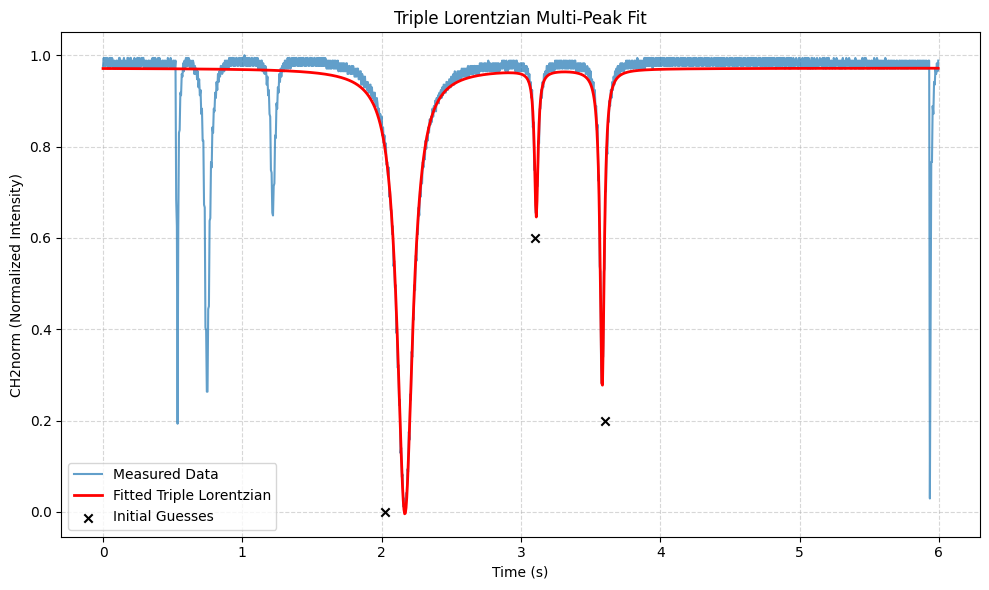

Lorentzian peak 1: 2.1746 ± 0.0011
Lorentzian peak 2: 4.0634 ± 0.0010
Lorentzian peak 3: 3.4342 ± 0.0019


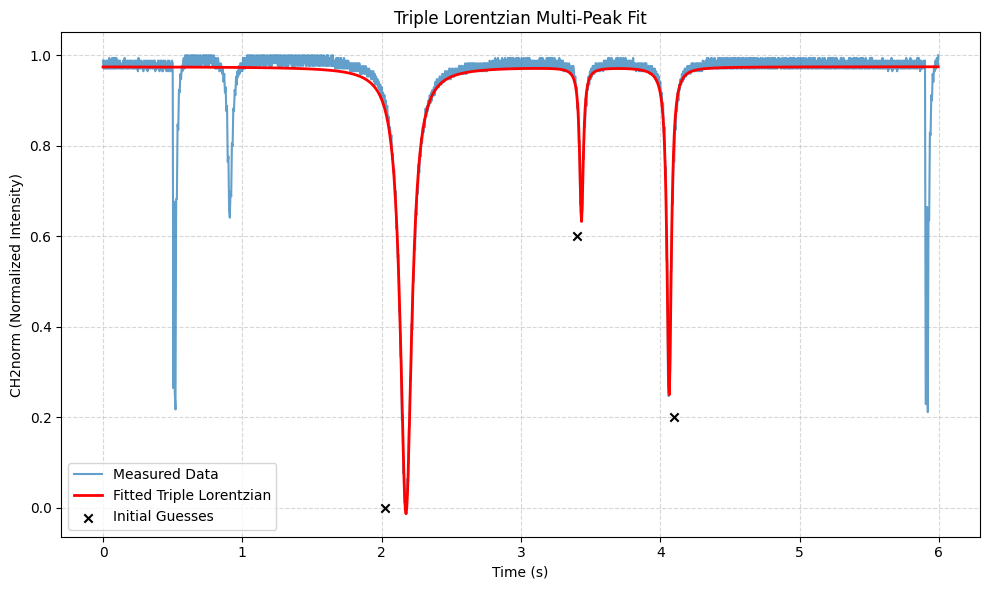

Lorentzian peak 1: 2.1610 ± 0.0014
Lorentzian peak 2: 4.5223 ± 0.0011
Lorentzian peak 3: 3.7356 ± 0.0021


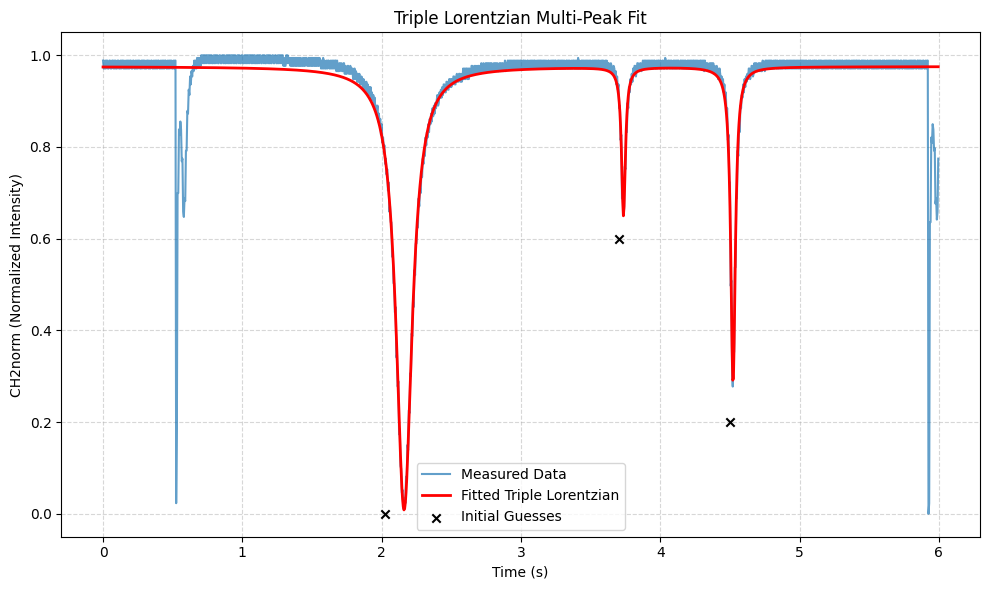

Lorentzian peak 1: 2.1777 ± 0.0008
Lorentzian peak 2: 5.0126 ± 0.0007
Lorentzian peak 3: 4.0688 ± 0.0014


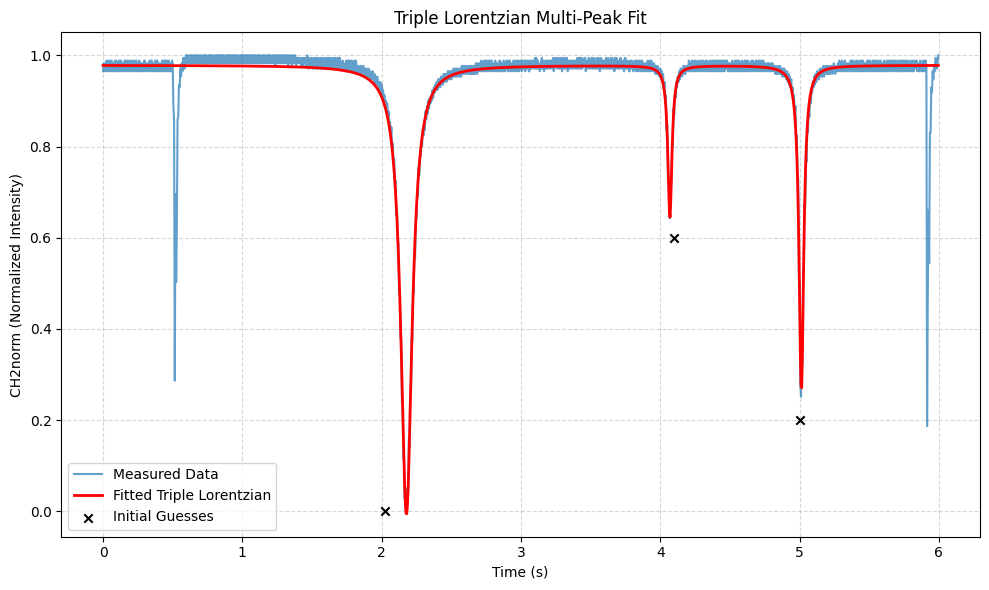

Lorentzian peak 1: 2.1726 ± 0.0010
Lorentzian peak 2: 5.4793 ± 0.0010
Lorentzian peak 3: 4.3788 ± 0.0020


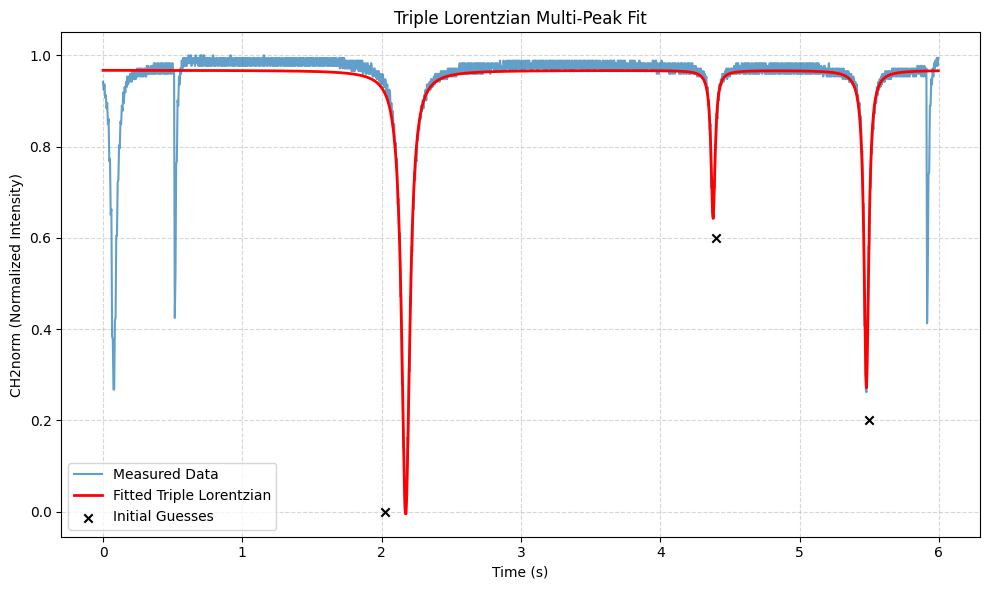

Lorentzian peak 1: 2.0287 ± 0.0006
Lorentzian peak 2: 5.7129 ± 0.0009
Lorentzian peak 3: 4.4885 ± 0.0018


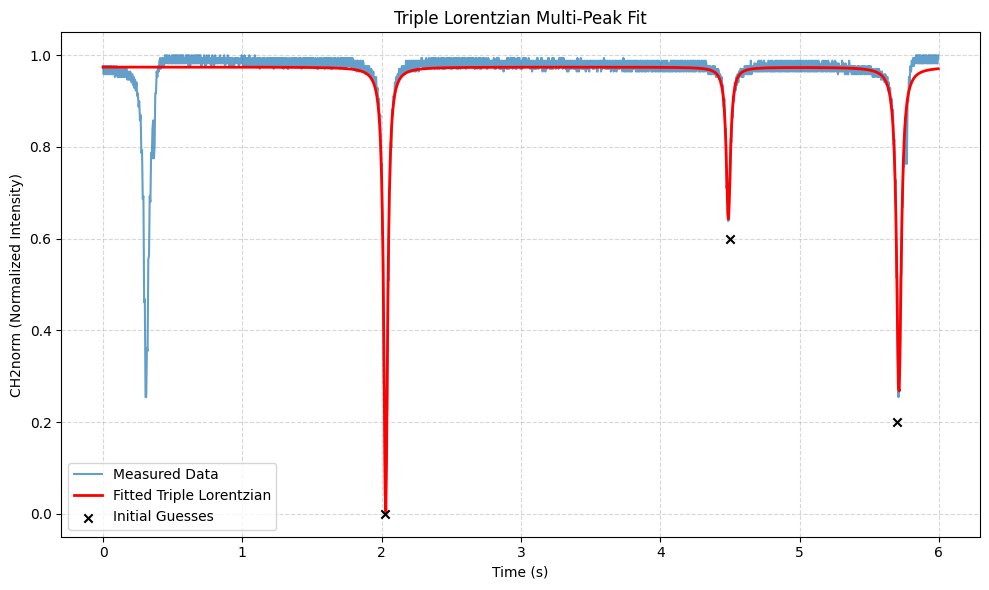

In [7]:
list_of_opt = []
p0guesses = [[1.0,0,2.025,0.018,0.2,2.5,0.023,0.6,2.3,0.022],
             [1.0,0,2.025,0.018,0.2,3.2,0.023,0.6,2.8,0.022],
             [1.0,0,2.025,0.018,0.2,3.6,0.023,0.6,3.1,0.022],
             [1.0,0,2.025,0.018,0.2,4.1,0.023,0.6,3.4,0.022],
             [1.0,0,2.025,0.018,0.2,4.5,0.023,0.6,3.7,0.022],
             [1.0,0,2.025,0.018,0.2,5.0,0.023,0.6,4.1,0.022],
             [1.0,0,2.025,0.018,0.2,5.5,0.023,0.6,4.4,0.022],
             [1.0,0,2.025,0.018,0.2,5.7,0.023,0.6,4.5,0.022]]
i = 0
for df_ in df:
    fit_triple_lorentzian(p0guesses[i],df_,list_of_opt)
    i = i+1

Lorentzian peak 1: 4.3435 ± 0.0002
Lorentzian peak 2: 2.4573 ± 0.0003


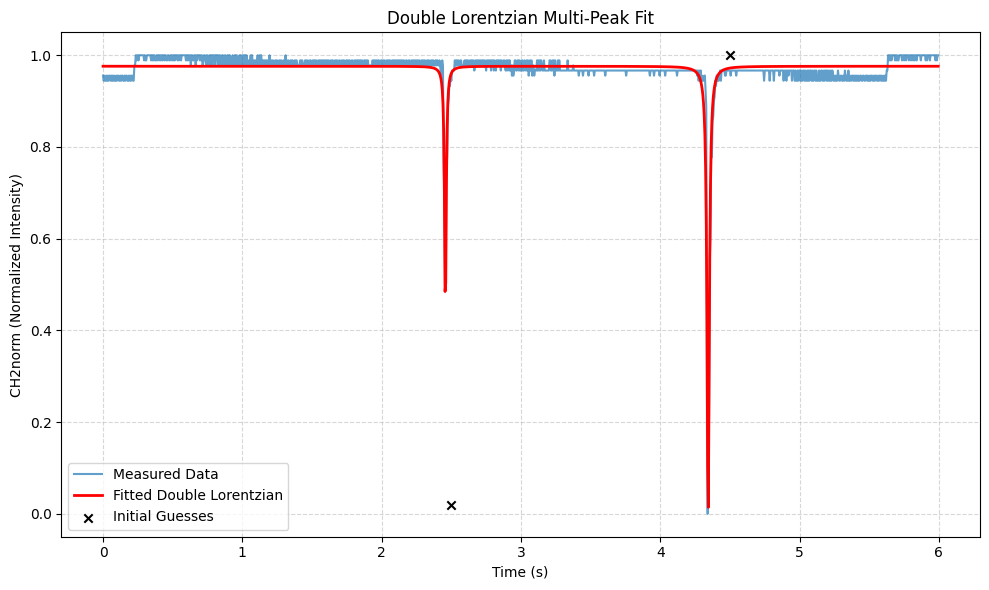

Lorentzian peak 1: 4.6008 ± 0.0002
Lorentzian peak 2: 1.3143 ± 0.0003


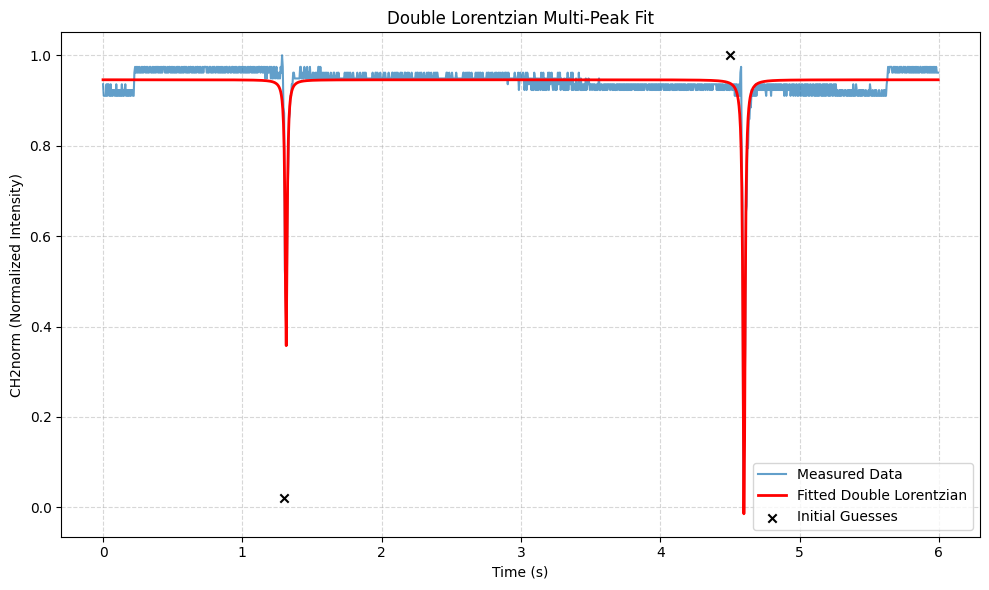

Lorentzian peak 1: 4.5623 ± 0.0003
Lorentzian peak 2: 0.7512 ± 0.0002


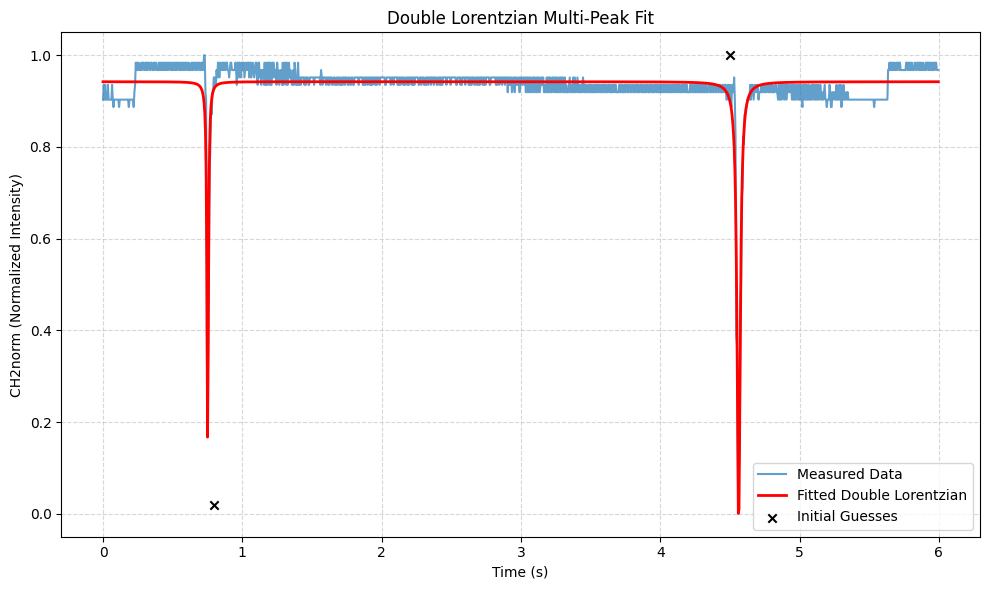

In [8]:
def fit_double_lorentzian(p0, df, result_list):
    x_data, y_data = df["time"], df["CH2norm"]
    # Ensure you have a 'double_lorentzian' model function defined
    popt, pcov = curve_fit(double_lorentzian, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    # Print centers for 2 peaks (indices 2 and 5)
    print(f"Lorentzian peak 1: {popt[2]:.4f} ± {perr[2]:.4f}")
    print(f"Lorentzian peak 2: {popt[5]:.4f} ± {perr[5]:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, double_lorentzian(x_data, *popt), 'r-', 
             linewidth=2, label='Fitted Double Lorentzian')
    plt.scatter([p0[2], p0[5]], [p0[0], p0[3]], 
                color='black', marker='x', label='Initial Guesses', zorder=5)
    plt.xlabel('Time (s)')
    plt.ylabel('CH2norm (Normalized Intensity)')
    plt.title('Double Lorentzian Multi-Peak Fit')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    result_list.append([popt[2], popt[5], perr[2], perr[5]])
    return popt, perr

p0guesses = [[1.0,0.0,4.5,0.02,0.4,2.5,0.02],
             [1.0,0.0,4.5,0.02,0.4,1.3,0.02],
             [1.0,0.0,4.5,0.02,0.4,0.8,0.02]]

i = 0
for df_ in dff:
    fit_double_lorentzian(p0guesses[i],df_,list_of_opt)
    i = i+1

Lorentzian peak 1: 4.0470 ± 0.0002


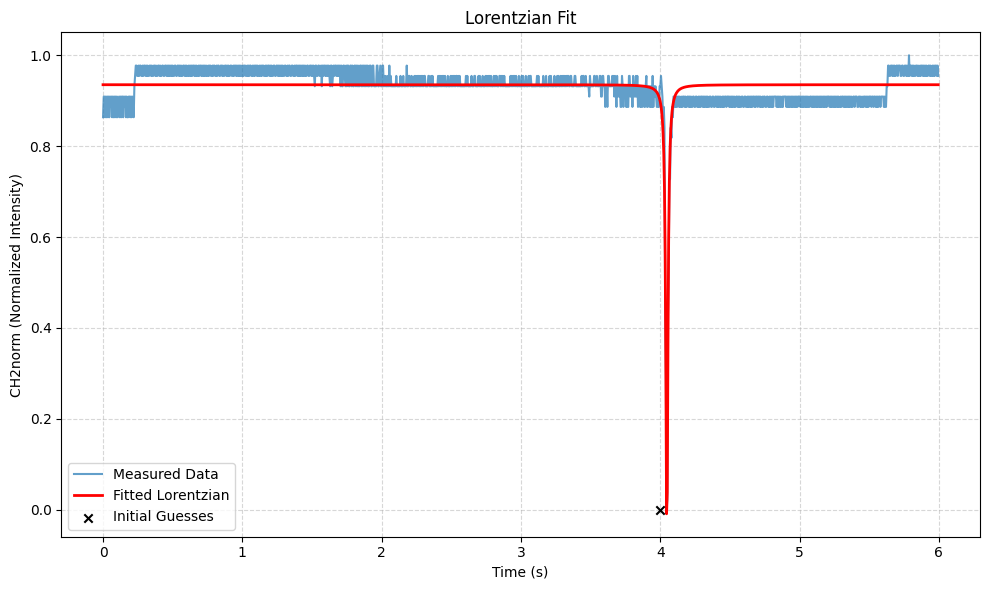

Lorentzian peak 1: 4.0260 ± 0.0002


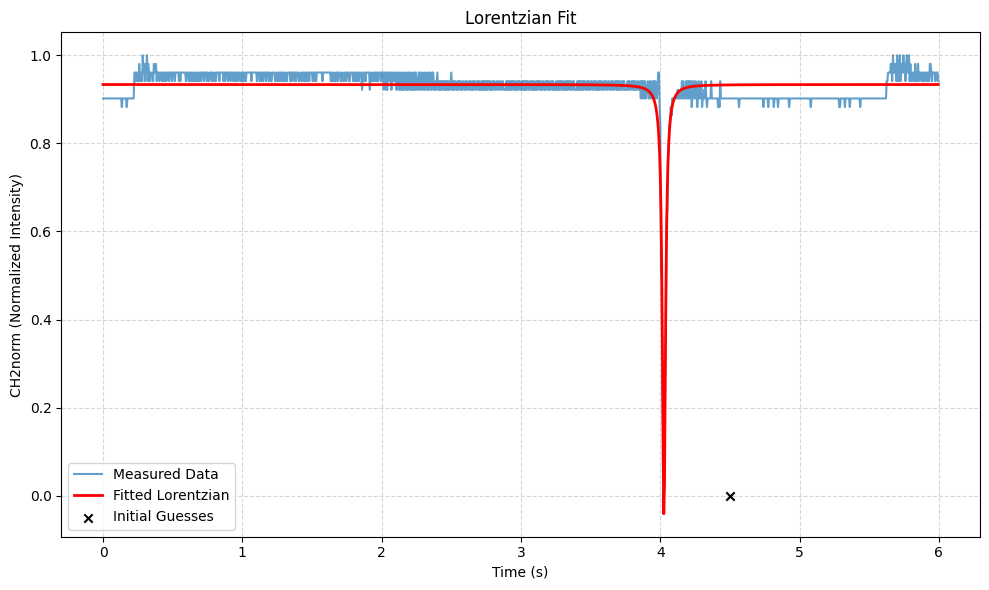

In [9]:
def fit_single_lorentzian(p0, df, result_list):
    x_data, y_data = df["time"], df["CH2norm"]
    # Ensure you have a 'double_lorentzian' model function defined
    popt, pcov = curve_fit(lorentzian, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    # Print centers for 2 peaks (indices 2 and 5)
    print(f"Lorentzian peak 1: {popt[2]:.4f} ± {perr[2]:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, lorentzian(x_data, *popt), 'r-', 
             linewidth=2, label='Fitted Lorentzian')
    plt.scatter([p0[2]], [p0[1]], 
                color='black', marker='x', label='Initial Guesses', zorder=5)
    plt.xlabel('Time (s)')
    plt.ylabel('CH2norm (Normalized Intensity)')
    plt.title('Lorentzian Fit')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    result_list.append([0,popt[2],0,perr[2]])
    return popt, perr

p0guesses = [[1.0,0.0,4.0,0.02],
             [1.0,0.0,4.5,0.02]]

i = 0
for df_ in dfff:
    fit_single_lorentzian(p0guesses[i],df_,list_of_opt)
    i = i+1

In [10]:
# list_of_opt entries: [peak2_time, peak3_time, err_peak2, err_peak3]
list_of_opt

[[np.float64(2.5016470058534837),
  np.float64(2.3443990707326954),
  np.float64(0.0007230646340538515),
  np.float64(0.0013892150540064567)],
 [np.float64(3.123095104849237),
  np.float64(2.8084798351956595),
  np.float64(0.0009597199217436241),
  np.float64(0.0019079319370380998)],
 [np.float64(3.5827341651825466),
  np.float64(3.1096092971658478),
  np.float64(0.0010875982712110512),
  np.float64(0.0021814966639154467)],
 [np.float64(4.063414287398456),
  np.float64(3.434244873385711),
  np.float64(0.0009537868183659782),
  np.float64(0.0018742772694119707)],
 [np.float64(4.522294036233055),
  np.float64(3.735584273355159),
  np.float64(0.001078211406545534),
  np.float64(0.002122429256303773)],
 [np.float64(5.0126427201271015),
  np.float64(4.068817978480627),
  np.float64(0.0007167531252223095),
  np.float64(0.0014489986115125268)],
 [np.float64(5.479346533224994),
  np.float64(4.378771966873504),
  np.float64(0.0010190309174920355),
  np.float64(0.0020173777935218276)],
 [np.floa

In [11]:
# 1. Organize DataFrames into a list for iterative access
dfs = [df_25, df_50, df_75, df_100, df_125, df_150, df_175, df_195, df_300, df_500, df_600]

def get_bfield_window(df, center_time, window_size=0.005):
    mask = (df['time'] >= center_time - window_size) & (df['time'] <= center_time + window_size)
    return df.loc[mask, 'Bfield'].mean()

def get_bfield_uncertainty(df, center_time, sigma_t, window_size=0.005):
    # Propagate time uncertainty sigma_t into B field uncertainty via dB/dt.
    # Also include a floor from the B field ADC resolution (CH1 step ~0.32V).
    ItB = 0.6 * 1e-4  # T/V conversion factor (same as add_magnetic_field)
    bfield_resolution = 0.32 * ItB / 10  # ~1.9e-6 T per ADC step
    mask = (df['time'] >= center_time - window_size) & (df['time'] <= center_time + window_size)
    sub = df.loc[mask]
    if len(sub) < 2:
        return bfield_resolution
    dBdt = np.polyfit(sub['time'], sub['Bfield'], 1)[0]
    unc_propagated = abs(dBdt) * sigma_t
    # Take the larger of propagated uncertainty and ADC floor
    return max(unc_propagated, bfield_resolution)

# After cell 6, result_list entries are [c2, c3, err_c2, err_c3]
peak2_times  = [r[0] for r in list_of_opt]
peak3_times  = [r[1] for r in list_of_opt]
peak2_errs   = [r[2] for r in list_of_opt]
peak3_errs   = [r[3] for r in list_of_opt]

lopt = [peak2_times, peak3_times]
lopt.append([25000, 50000, 75000, 100000, 125000, 150000, 175000, 195000, 300000, 500000, 600000])

# B field values at each peak
bfield_peak2 = [get_bfield_window(df, lopt[0][i]) for i, df in enumerate(dfs)]
bfield_peak3 = [get_bfield_window(df, lopt[1][i]) for i, df in enumerate(dfs)]
lopt.append(bfield_peak2)
lopt.append(bfield_peak3)

# B field uncertainties propagated from Lorentzian fit time uncertainties
bfield_unc_peak2 = [get_bfield_uncertainty(dfs[i], lopt[0][i], peak2_errs[i]) for i in range(len(dfs))]
bfield_unc_peak3 = [get_bfield_uncertainty(dfs[i], lopt[1][i], peak3_errs[i]) for i in range(len(dfs))]

# Frequency uncertainty: assume +/- 1 kHz (oscilloscope/generator resolution)
freq_unc = 1000  # Hz

In [12]:
# Plotting with uncertainties is handled in the next cell.

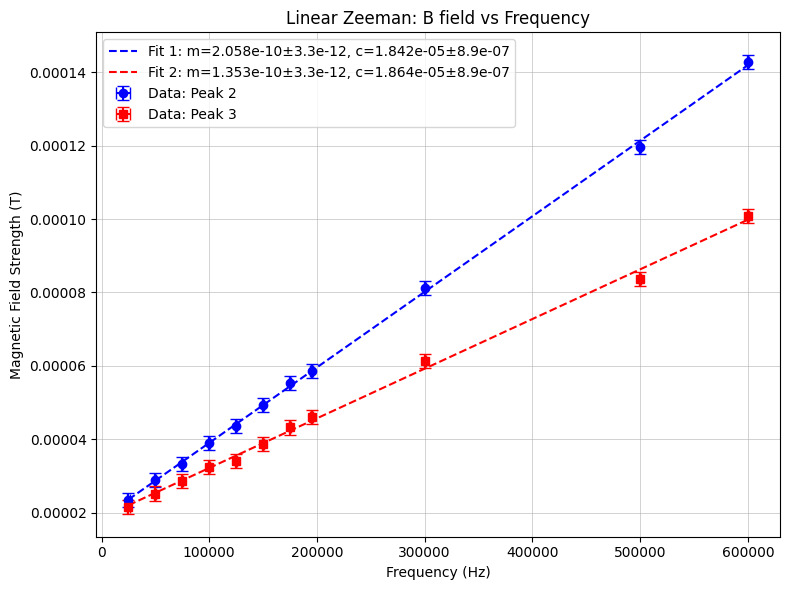

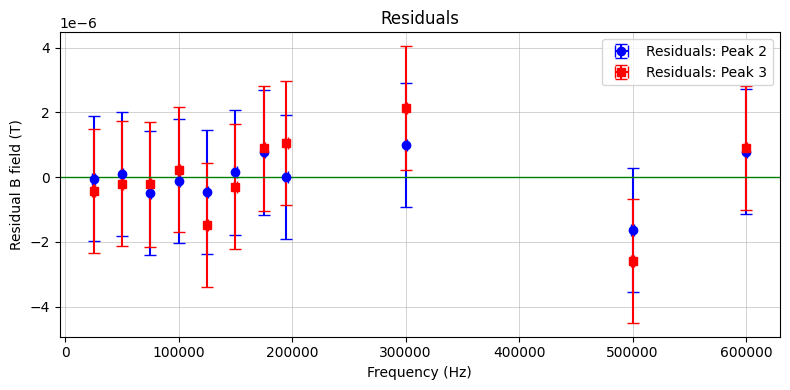

In [13]:
x = np.array(lopt[2])          # frequencies
y1 = np.array(lopt[3])         # B field at peak 2
y2 = np.array(lopt[4])         # B field at peak 3
ey1 = np.array(bfield_unc_peak2)  # B field uncertainties peak 2
ey2 = np.array(bfield_unc_peak3)  # B field uncertainties peak 3
ex = np.full_like(x, freq_unc, dtype=float)  # frequency uncertainties

# Weighted linear fits using B field uncertainties as weights
w1 = 1.0 / ey1**2
w2 = 1.0 / ey2**2

def weighted_polyfit(x, y, w):
    # Weighted least-squares linear fit
    S  = np.sum(w)
    Sx = np.sum(w * x)
    Sy = np.sum(w * y)
    Sxx = np.sum(w * x**2)
    Sxy = np.sum(w * x * y)
    D = S * Sxx - Sx**2
    m = (S * Sxy - Sx * Sy) / D
    c = (Sxx * Sy - Sx * Sxy) / D
    # Covariance
    sigma_m = np.sqrt(S / D)
    sigma_c = np.sqrt(Sxx / D)
    return m, c, sigma_m, sigma_c

m1, c1_fit, sm1, sc1 = weighted_polyfit(x, y1, w1)
m2, c2_fit, sm2, sc2 = weighted_polyfit(x, y2, w2)

x_line = np.linspace(x.min(), x.max(), 300)

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(x, y1, yerr=ey1, xerr=ex, fmt='o', color='blue',
            capsize=4, label='Data: Peak 2')
ax.errorbar(x, y2, yerr=ey2, xerr=ex, fmt='s', color='red',
            capsize=4, label='Data: Peak 3')
ax.plot(x_line, m1 * x_line + c1_fit, color='blue', linestyle='--',
        label=f'Fit 1: m={m1:.3e}\u00b1{sm1:.1e}, c={c1_fit:.3e}\u00b1{sc1:.1e}')
ax.plot(x_line, m2 * x_line + c2_fit, color='red', linestyle='--',
        label=f'Fit 2: m={m2:.3e}\u00b1{sm2:.1e}, c={c2_fit:.3e}\u00b1{sc2:.1e}')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnetic Field Strength (T)')
ax.set_title('Linear Zeeman: B field vs Frequency')
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.8)
ax.legend()
plt.tight_layout()
plt.show()

# Residuals
res1 = y1 - (m1 * x + c1_fit)
res2 = y2 - (m2 * x + c2_fit)

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.errorbar(x, res1, yerr=ey1, xerr=ex, fmt='o', color='blue',
             capsize=4, label='Residuals: Peak 2')
ax2.errorbar(x, res2, yerr=ey2, xerr=ex, fmt='s', color='red',
             capsize=4, label='Residuals: Peak 3')
ax2.axhline(0, color='green', linewidth=1)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Residual B field (T)')
ax2.set_title('Residuals')
ax2.grid(True, linestyle='-', linewidth=0.5, alpha=0.8)
ax2.legend()
plt.tight_layout()
plt.show()